<a href="https://colab.research.google.com/github/shayesteh99/DecoDiPhy/blob/main/DecoDiPhy_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DecoDiPhy: Deconvolving Phylogenetic Distance Mixtures

Decodiphy is a tool that helps you decipher a metagenomic sample by finding a multi-placements for a mixture sample on a reference phylogeny.

##Installation

You can install DecoDiPhy using bioconda or directly from github:

In [49]:
# Install DecoDiPhy from GitHub
!pip install git+https://github.com/shayesteh99/DecoDiPhy.git > /dev/null 2>&1
print("Successfully installed DecoDiPhy")

## Alternative Installation: Bioconda

If you use Conda or Mamba, you can install DecoDiPhy from Bioconda:

```bash
conda install -c conda-forge -c bioconda decodiphy
```

or (recommended, faster):

```bash
mamba install -c conda-forge -c bioconda decodiphy
```

Verify the installation:

```bash
decodiphy --help
```

In [31]:
# Download example data
!git clone https://github.com/shayesteh99/DecoDiPhy.git

# Move into repo
%cd DecoDiPhy

Cloning into 'DecoDiPhy'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 219 (delta 97), reused 138 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (219/219), 10.62 MiB | 9.74 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/DecoDiPhy/DecoDiPhy


In [32]:
!decodiphy --help

DecoDiPhy 1.5.0
usage: decodiphy [-h] [-t TREE] [-d DISTANCES] [-a ASSIGNMENTS] [-j JPLACE]
                 [-s SEED] [-f FIX_K] [-k K] [-q QUICK] [-r RADIUS]
                 [-m {hill,exhaustive,closest,closest_iterative,reverse_hill}]
                 [-o OUTDIR] [--min_p MIN_P] [--warm_start WARM_START]
                 [--score SCORE] [--optimizer {osqp,cvxpy}]

options:
  -h, --help            show this help message and exit
  -t TREE, --tree TREE  Input tree (default: None)
  -d DISTANCES, --distances DISTANCES
                        Distance file (default: None)
  -a ASSIGNMENTS, --assignments ASSIGNMENTS
                        A placement file with two columns: labels and counts
                        (default: None)
  -j JPLACE, --jplace JPLACE
                        jplace file (default: None)
  -s SEED, --seed SEED  Random Seed (default: 1142)
  -f FIX_K, --fix_k FIX_K
                        Fix k (default: 0)
  -k K, --k K           Number of query taxa if fix_k==1 o

We also need to install a few R packages for drawing purposes of this tutorial. Not required for running DecoDiPhy.

In [24]:
!R -e "install.packages(c('ggplot2','jsonlite','stringr','dplyr','viridisLite','ape'), repos='https://cloud.r-project.org')" > /dev/null 2>&1
!R -e "if(!requireNamespace('BiocManager', quietly=TRUE)) install.packages('BiocManager', repos='https://cloud.r-project.org'); BiocManager::install(c('treeio','ggtree'), ask=FALSE, update=FALSE)" > /dev/null 2>&1
print("Successfully installed R dependencies!")

## Example: running DecoDiPhy on an IBD sample

We will follow this tutorial to understand how DecoDiPhy can help with interpretability of metagenomic samples. This sample is taken from the IBD dataset published by [Franzosa et al. 2019](https://doi.org/10.1038/s41564-018-0306-4). We will only look at a particular region of the reference tree (*Oscillospiraceae* family), which is a very well-studied family of bacteria in the context of IBD. The full 16k-taxon reference tree was published in [Balaban et al. 2024](https://doi.org/10.1038/s41587-023-01868-8). For the full analysis of the IBD dataset and more, see [Arasti et al. 2026](https://doi.org/10.64898/2026.01.18.700179).

###krepp results
We use the following R script to show krepp results on this sample. Please note that the original jplace output from krepp has been downsampled 10 times to save disc space.

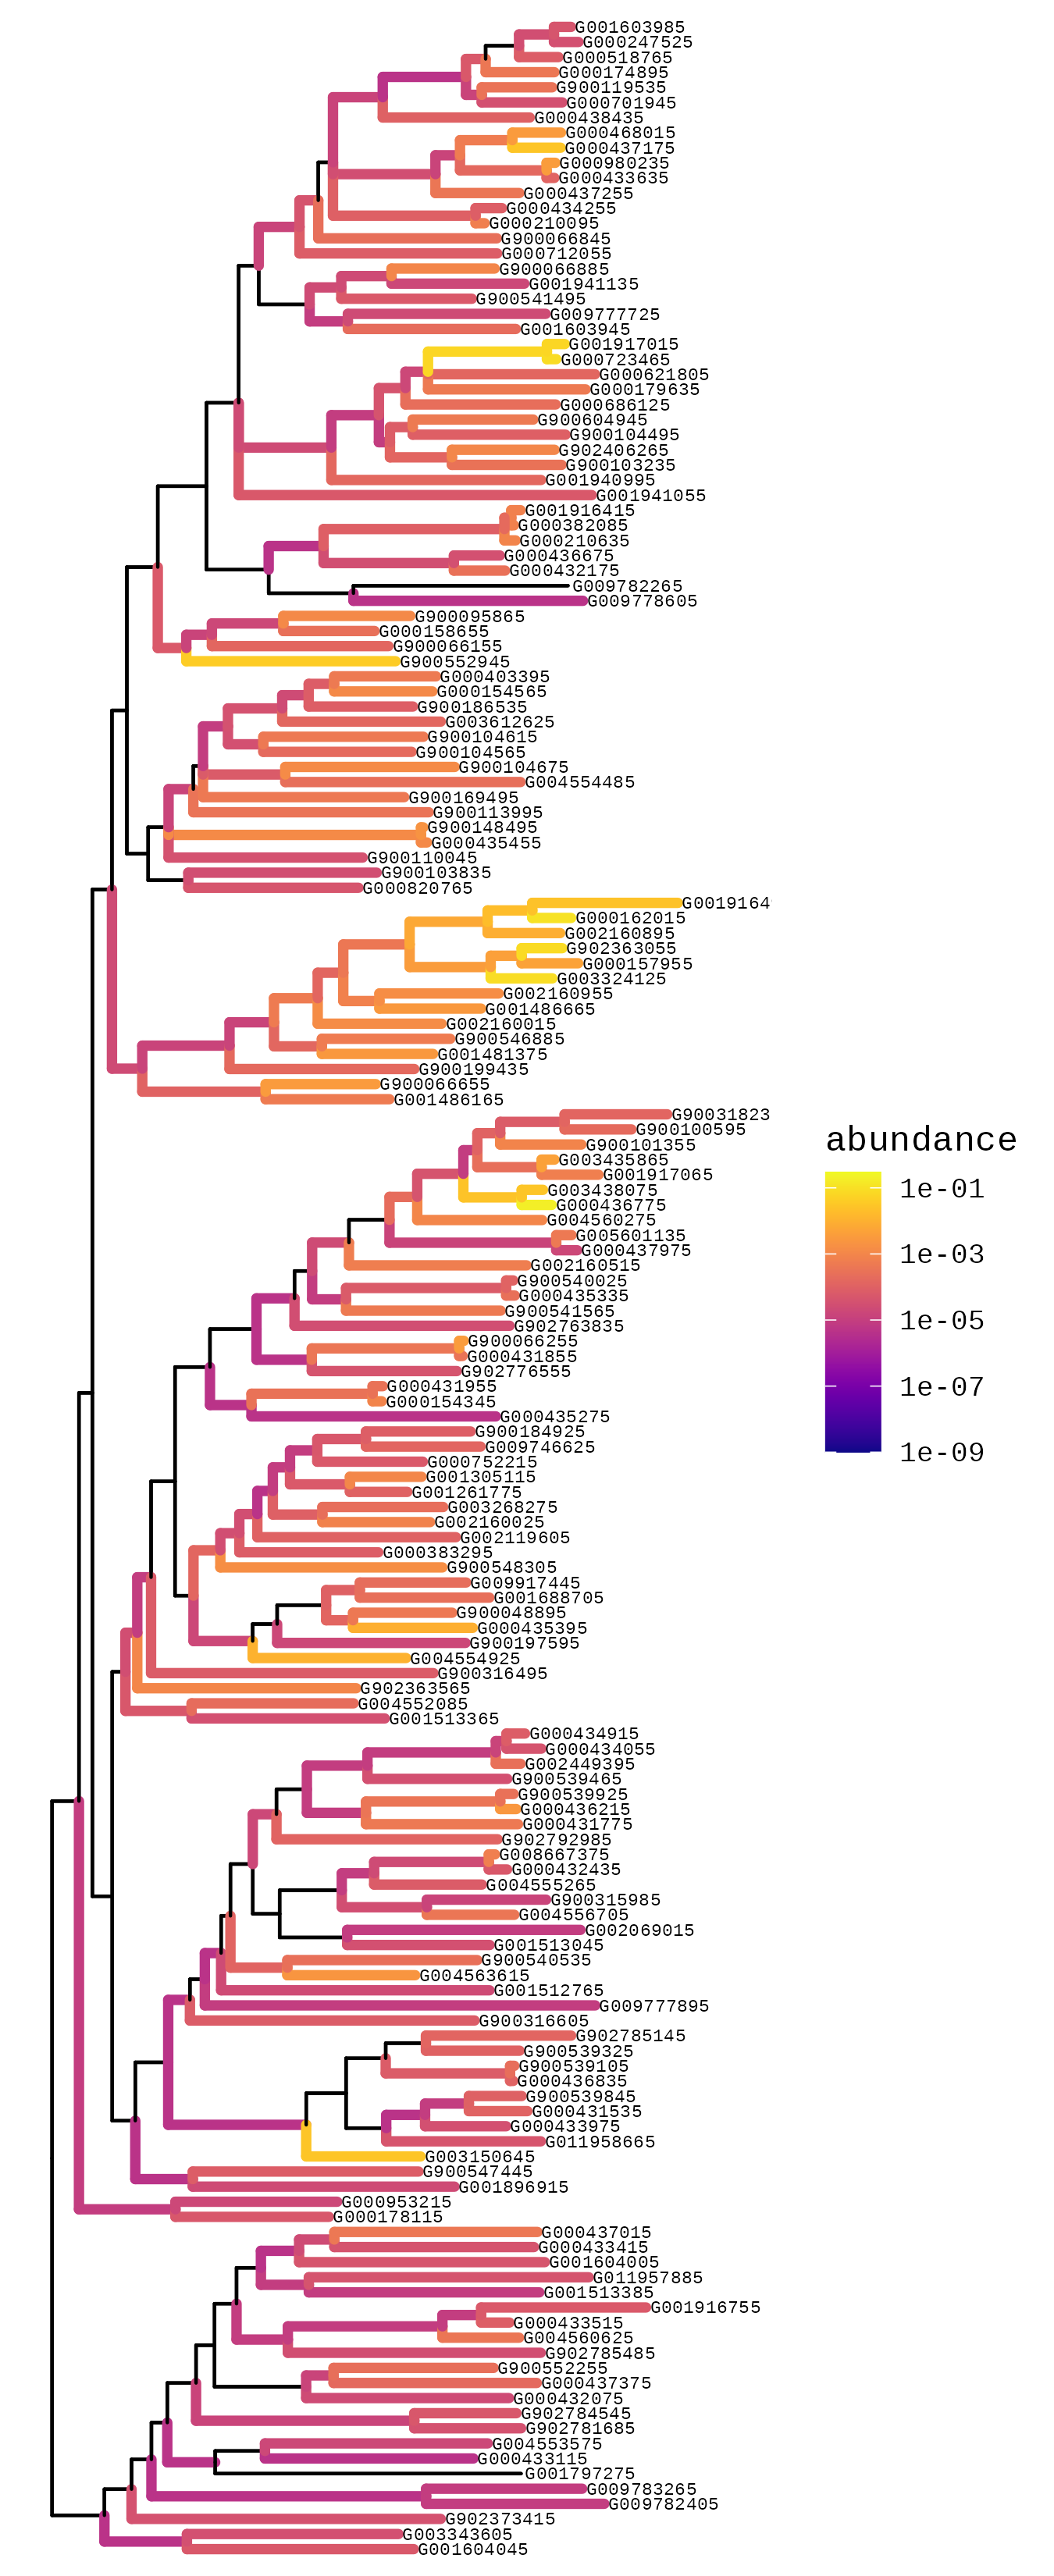

In [38]:
!Rscript MISC/draw_placements.R Example/krepp_multiplacement.jplace "unweighted" Example/krepp_results.png > /dev/null 2>&1
from IPython.display import Image
Image("Example/krepp_results.png", width=400)

##DecoDiPhy Results

To run DecoDiPhy, you can use the jplace output from krepp directly as input to DecoDiPhy. In this case, DecoDiPhy will automatically adjust the number of placements based on the total number of mapped reads in krepp output.

In [39]:
!decodiphy -j Example/krepp_multiplacement.jplace -o Example/output

DecoDiPhy 1.5.0
Total number of reads: 217073.0
Input tree was not labeled! The labeled tree is saved in  Example/output/labeled_tree.trees
Input matrices created!
k =  1
Optimal Placements:  N6823
Loss:  0.3742371347075695
k =  2
Optimal Placements:  N6823 G000436775
Loss:  0.18706515116124864
k =  3
Optimal Placements:  N9296 N11749 N9299
Loss:  0.010488618406128195
k =  4
Optimal Placements:  N9296 N12156 N10791 N7313
Loss:  0.004520466745135359
k =  5
Optimal Placements:  N9296 N12156 N10791 N11752 N6819
Loss:  0.0019069025857579229
k =  6
Optimal Placements:  G000162015 G000436775 N10791 N11286 N6336 N9790
Loss:  0.0007276472574584199
k =  7
Optimal Placements:  G000162015 G000436775 N10791 N10794 N6821 N9295 G003150645
Loss:  0.00047723004952185996
k =  8
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945
Loss:  5.866468819894456e-05
k =  9
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945 N8307
Loss:  4.18263

## Understanding DecoDiPhy output files

After running DecoDiPhy, two main output files are generated:

1. `output.jplace`
2. `all_rounds.json`

Each file contains different information about the placement results.

---

# 1. Jplace output (`output.jplace`)

The `output.jplace` file contains the final placement results produced by DecoDiPhy. It follows the standard **jplace format** introduced by Matsen et al. (2012), allowing the output to be visualized and analyzed using existing phylogenetic placement tools.

A jplace file contains four main components:

* `fields`: Defines the information stored for each placement.
* `metadata`: Contains information about the DecoDiPhy run.
* `placements`: Contains the placement locations and abundances.
* `tree`: The reference phylogeny used for placement.

Example:

```json
"fields": [
    "edge_num",
    "abundance",
    "x",
    "y"
]
```

Each placement contains:

```json
{
    "n": "q1",
    "p": [
        [
            164,
            0.2577,
            0.7873,
            0.0017
        ]
    ]
}
```

The values correspond to:

| Field       | Description                                                      |
| ----------- | ---------------------------------------------------------------- |
| `edge_num`  | The edge number in the reference tree where the placement occurs |
| `abundance` | The relative abundance assigned to this placement                |
| `x`         | Relative position along the placement branch                     |
| `y`         | Terminal branch length associated with the placement             |

For example, the placement above indicates that sample `q1` is placed on edge `164` with an abundance of approximately `0.258`.

The `tree` field contains the reference tree in Newick format. Internal branches are labeled with edge numbers that correspond to the `edge_num` values in the placement table.

The jplace format allows DecoDiPhy outputs to be directly used by phylogenetic visualization and analysis software that supports jplace files.

---

# 2. Optimization history output (`all_rounds.json`)

The `all_rounds.json` file contains detailed information from every optimization step performed by DecoDiPhy.

Unlike `output.jplace`, which contains only the final placements, this file stores the complete search history. It can be useful for:

* Understanding how many placements DecoDiPhy identified.
* Examining how the optimization improves with additional placements.
* Recovering additional placements without restarting the optimization.
* Comparing solutions with different numbers of placements.

Each JSON object corresponds to one optimization round for a given number of placements (`k`).

Example:

```json
{
    "k": 2,
    "rounds": 2,
    "loss": 0.18706515116124864,
    "anchors": [
        "N6823",
        "G000436775"
    ],
    "p": [
        0.7983,
        0.2017
    ],
    "x": [
        0.2433,
        0.0
    ],
    "y": [
        0.1896,
        0.0080
    ],
    "runtime": 0.0583,
    "opttime": 0.00017
}
```

The fields are:

| Field     | Description                                                          |
| --------- | -------------------------------------------------------------------- |
| `k`       | Number of placements in this solution                                |
| `rounds`  | Number of optimization iterations performed                          |
| `loss`    | Final optimization loss value                                        |
| `anchors` | Reference taxa or internal nodes used as initial placement locations |
| `p`       | Relative abundance assigned to each placement                        |
| `x`       | Relative position of each placement on its branch                    |
| `y`       | Terminal branch length estimates                                     |
| `runtime` | Total runtime for this optimization                                  |
| `opttime` | Runtime spent in the convex optimization step                               |                                |

The final object in `all_rounds.json` corresponds to the solution written to `output.jplace`.

Because all intermediate solutions are retained, users can explore solutions with fewer or more placements without rerunning the entire optimization. For example, if DecoDiPhy initially stopped with 5 placements but a higher-resolution result is desired, the search can be continued using the existing `all_rounds.json` file as a warm start. See the section "Resume DecoDiPhy Execution"


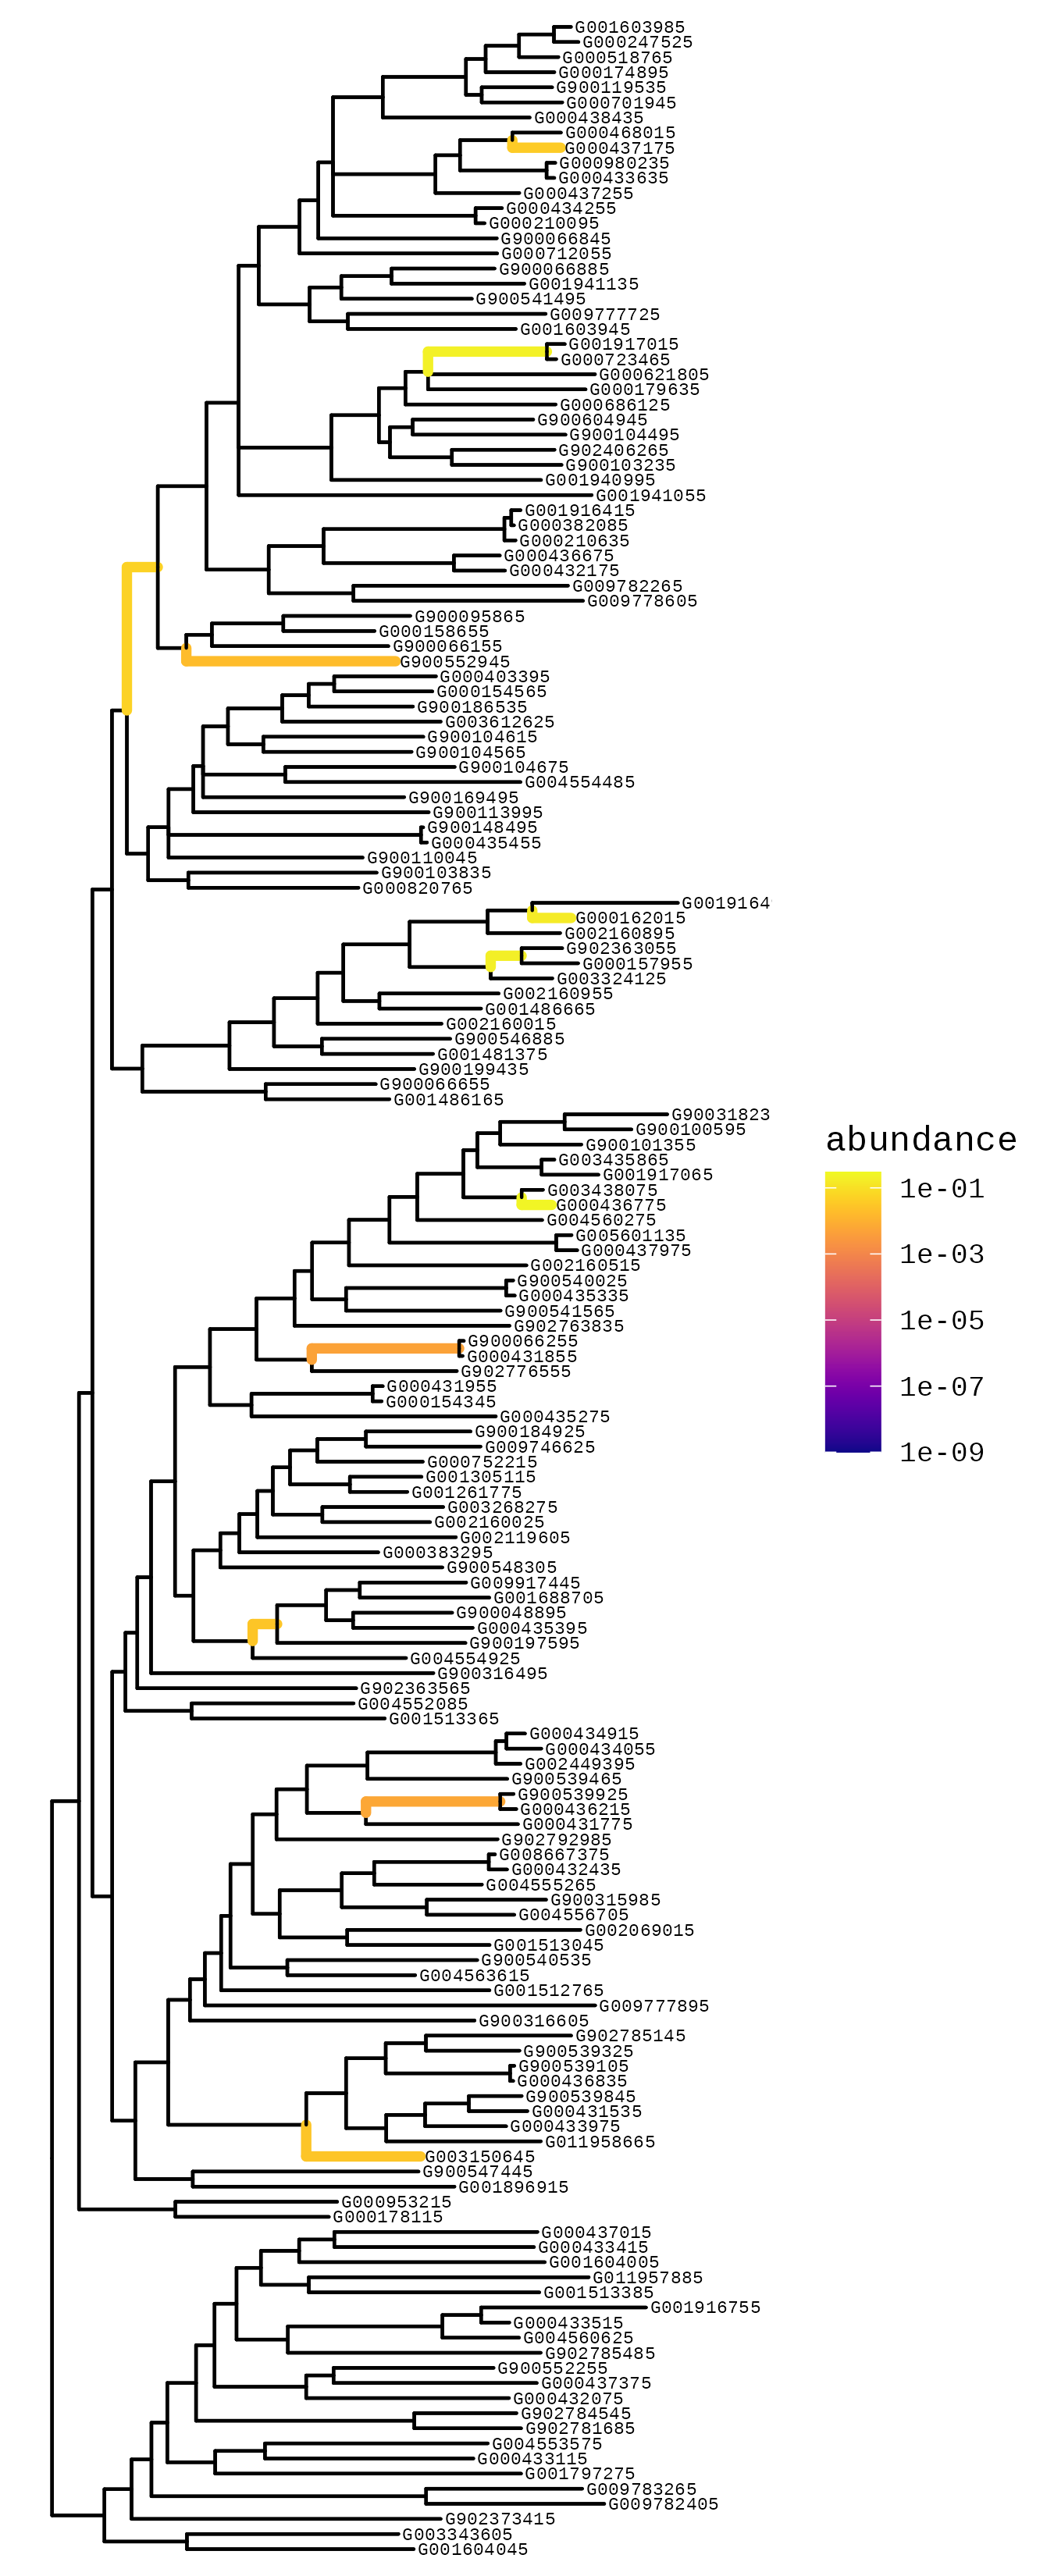

In [41]:
!Rscript MISC/draw_placements.R Example/output/output.jplace "weighted" Example/output/DecoDiPhy_results.png > /dev/null 2>&1
from IPython.display import Image
Image("Example/output/DecoDiPhy_results.png", width=400)

# Input formats supported by DecoDiPhy

DecoDiPhy can accept three different types of inputs depending on how the sample information has been generated.

All three approaches ultimately provide DecoDiPhy with two key pieces of information:

1. A **reference phylogeny** containing the taxa where placements can occur.
2. Information describing the relationship between the sample and the reference taxa.

The three supported input formats are:

1. A jplace file generated by **krepp**
2. An assignment file together with a reference tree
3. A distance vector together with a reference tree

---

## 1. Using a krepp jplace output

If you have already generated phylogenetic placements using **krepp**, DecoDiPhy can directly use the jplace output.

The krepp output contains placements of individual reads on the reference tree. DecoDiPhy first converts these individual placements into distances and then performs placement consolidation.

### Input files

Required:

* `krepp_multiplacement.jplace`

  * jplace file containing read placements
  * generated by krepp
* Reference tree used by krepp


Run:
```bash
decodiphy \
    -j Example/krepp_multiplacement.jplace \
    -o Example/output
```

---

# 2. Using an assignment file and reference tree

If individual reads have already been assigned to taxa or internal edges in the reference tree, DecoDiPhy can use this information directly.

This input format is useful when a read classifier or phylogenetic placement method produces assignments but not a distance vector.

### Input files

Required:

* Read-assignment file
* Reference tree

The read-assignment file should contain the number (or abundance) of reads assigned to each reference taxon or edge. The first column correspond to the reference id and the second column corresponds to counts or abundances.

Example format:

```
G000436775      104402
G001604045      3435
G000436775      7856
```

Run:
```bash
decodiphy \
    -a Example/krepp_assignments.txt
    -t Example/reference_tree.trees \
    -o Example/output
```

---

# 3. Using a distance vector and reference tree

The most direct input format for DecoDiPhy is a distance vector describing the distance between the sample and every reference taxon.

This format is useful when distances have already been computed using another method.

### Input files

Required:

* Reference tree in Newick format
* Distance vector file

Example distance file:

```
G001604045    0.32
G003343605    0.28
G902373415    0.41
G009782405    0.37
```

Each line contains:

```
reference_taxon    distance
```

where the distance represents the evolutionary distance between the sample and the reference taxon.

### Run DecoDiPhy

```bash
decodiphy \
    -d Example/distances.txt \
    -t Example/pruned_tree.trees \
    -o Example/output
```

---


In [44]:
!decodiphy -a Example/krepp_assignments.txt -t Example/reference_tree.trees -o Example/output

DecoDiPhy 1.5.0
Total number of reads: 217073.0
Input matrices created!
k =  1
Optimal Placements:  N6823
Loss:  0.3742371347075695
k =  2
Optimal Placements:  N6823 G000436775
Loss:  0.18706515116124864
k =  3
Optimal Placements:  N9296 N11749 N9299
Loss:  0.010488618406128195
k =  4
Optimal Placements:  N9296 N12156 N10791 N7313
Loss:  0.004520466745135359
k =  5
Optimal Placements:  N9296 N12156 N10791 N11752 N6819
Loss:  0.0019069025857579229
k =  6
Optimal Placements:  G000162015 G000436775 N10791 N11286 N6336 N9790
Loss:  0.0007276472574584199
k =  7
Optimal Placements:  G000162015 G000436775 N10791 N10794 N6821 N9295 G003150645
Loss:  0.00047723004952185996
k =  8
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945
Loss:  5.866468819894456e-05
k =  9
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945 N8307
Loss:  4.182630313440304e-05
k =  10
Optimal Placements:  G000162015 G000436775 N10791 N11752 N9290 N9790 

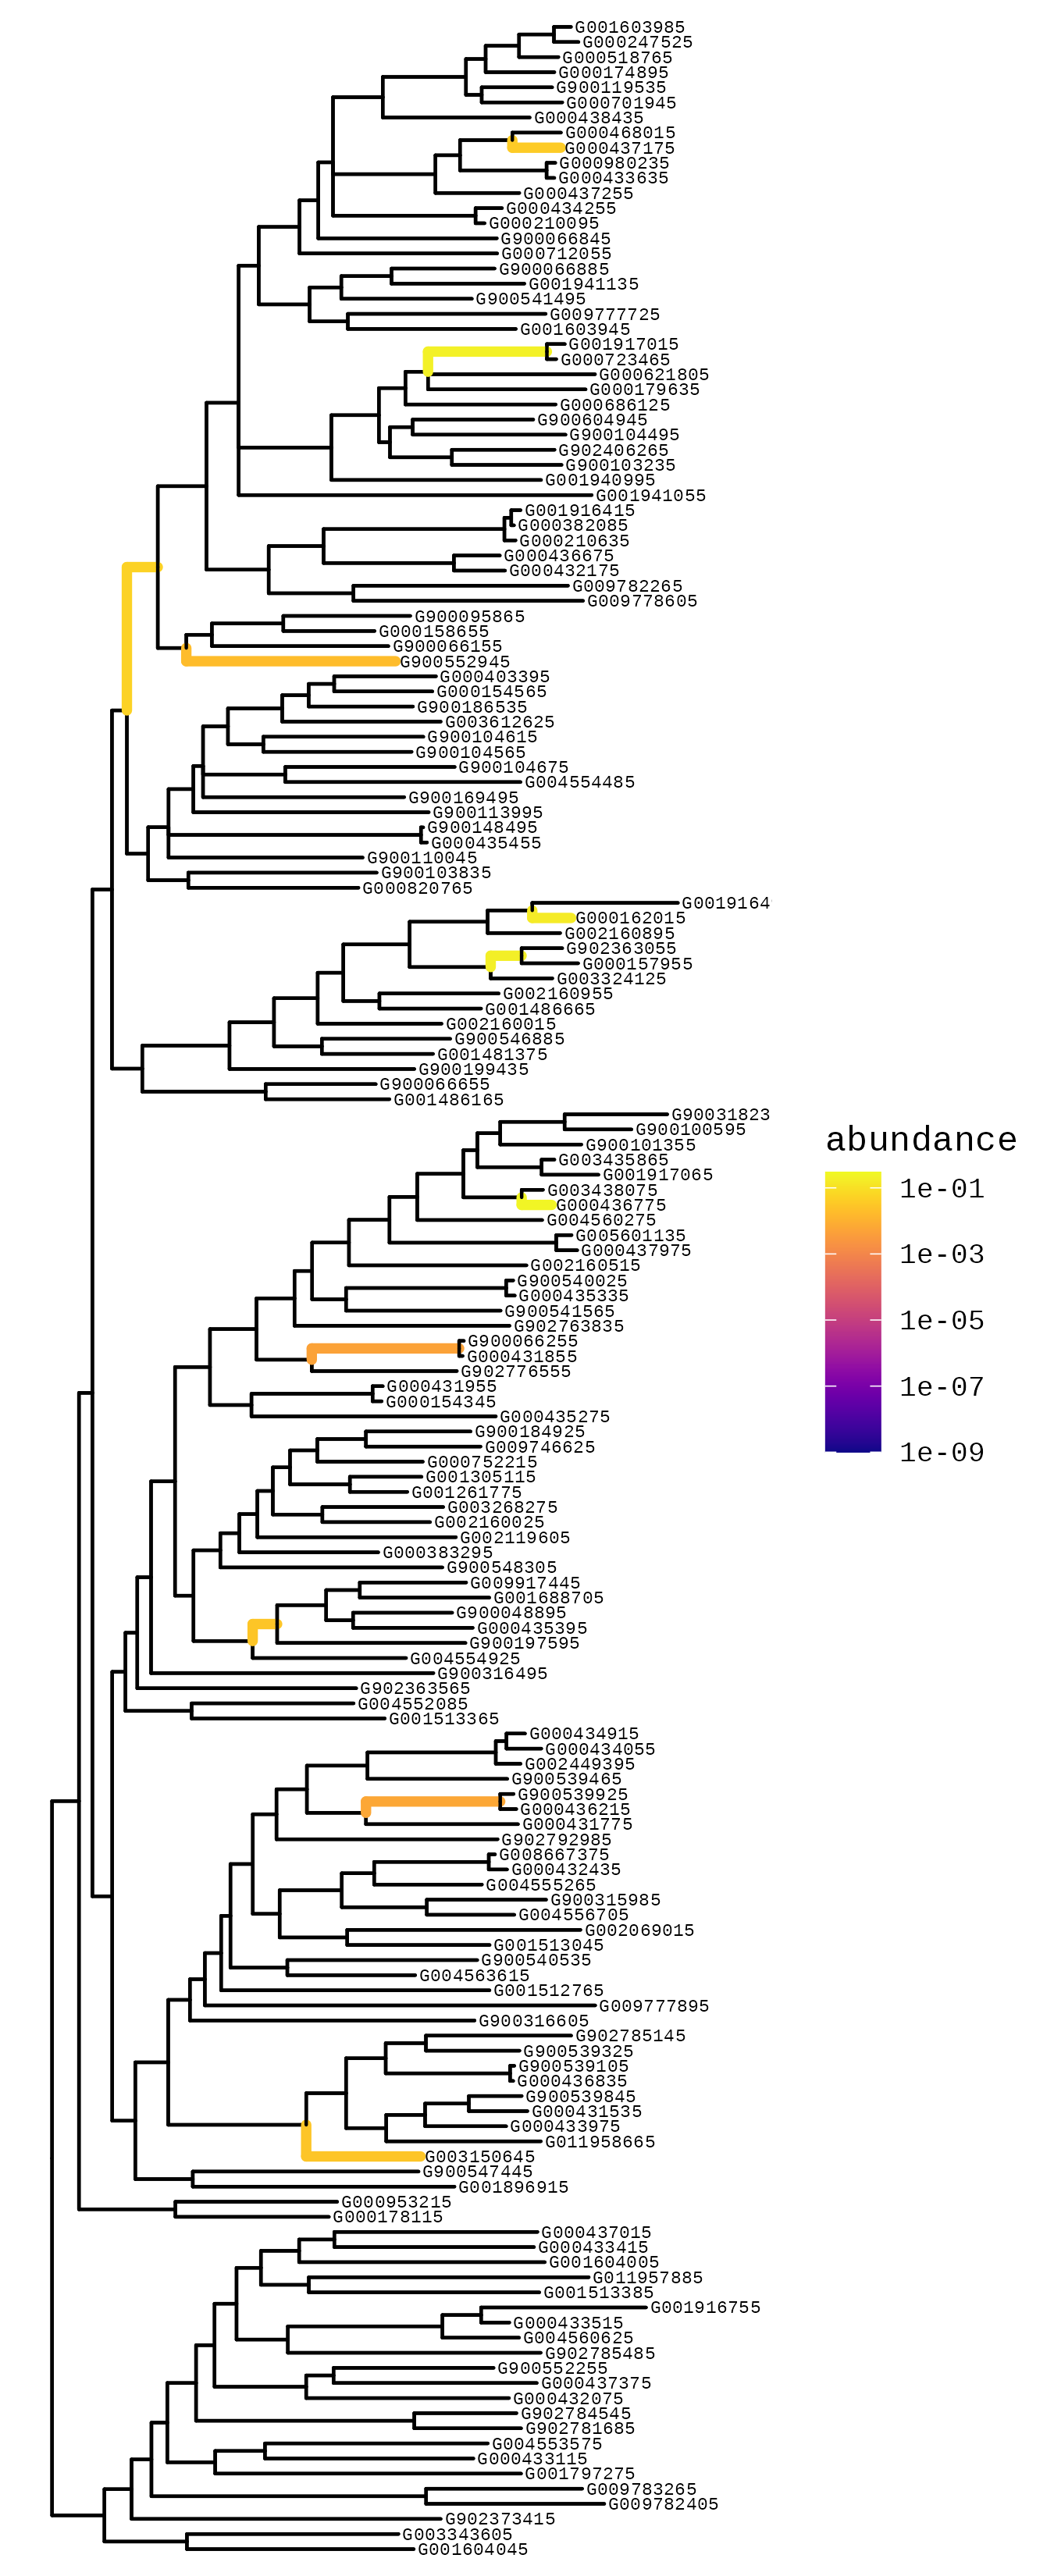

In [45]:
!Rscript MISC/draw_placements.R Example/output/output.jplace "weighted" Example/output/DecoDiPhy_results.png > /dev/null 2>&1
from IPython.display import Image
Image("Example/output/DecoDiPhy_results.png", width=400)

# Controlling the number of placements

One of the key parameters in DecoDiPhy is the number of placements it returns. Rather than requiring the user to specify this value in every analysis, DecoDiPhy can automatically determine an appropriate number of placements based on the amount of sequencing data available. Alternatively, users can manually control the resolution of the output.

There are three ways to control the number of placements.

---

## 1. Automatic selection (recommended)

By default, DecoDiPhy automatically determines how many placements to report.

When the input is a **jplace file** or a **read-assignment file** that includes read counts, DecoDiPhy uses the total number of reads to determine the minimum abundance that a placement must have to be reported.

The default stopping criterion is

```text
minimum abundance = 1000 / total number of reads
```

For example:

| Total reads | Default minimum abundance |
| ----------: | ------------------------: |
|      10,000 |                      0.10 |
|      50,000 |                      0.02 |
|     100,000 |                      0.01 |
|   1,000,000 |                     0.001 |

During optimization, DecoDiPhy continues adding placements until every remaining placement would have an abundance below this threshold.

If the total number of reads is **not available** (for example, when only a distance vector is provided), DecoDiPhy instead uses a default minimum abundance of ```0.01```.

This automatic behavior provides a good balance between resolution and robustness for most datasets.

---

## 2. Manually choosing the minimum abundance

You can override the automatic threshold using the `--min_p` option.

```bash
decodiphy \
    -j Example/krepp_multiplacement.jplace \
    --min_p 0.005 \
    -o Example/output
```

The minimum abundance controls the smallest placement that DecoDiPhy is allowed to report.

* **Larger values** (e.g. `0.05`) stop the optimization earlier and produce **fewer placements**.
* **Smaller values** (e.g. `0.001`) allow DecoDiPhy to detect **more placements**, including low-abundance components.

In general:

* Higher `--min_p` → simpler, lower-resolution solutions.
* Lower `--min_p` → more detailed, higher-resolution solutions.

---

## 3. Specifying the exact number of placements

If you already know how many placements you want, DecoDiPhy can return exactly that number.

To do this, combine the `-k` option with the `-f 1` flag:

```bash
decodiphy \
    -j Example/krepp_multiplacement.jplace \
    -k 5 \
    -f 1 \
    -o Example/output
```

This instructs DecoDiPhy to continue the optimization until it finds exactly **5 placements**, regardless of the automatic stopping criteria.

---

In [50]:
!decodiphy -a Example/krepp_assignments.txt -t Example/reference_tree.trees -f 1 -k 20 -o Example/output

DecoDiPhy 1.5.0
Total number of reads: 217073.0
Input matrices created!
k =  1
Optimal Placements:  N6823
Loss:  0.3742371347075695
k =  2
Optimal Placements:  N6823 G000436775
Loss:  0.18706515116124864
k =  3
Optimal Placements:  N9296 N11749 N9299
Loss:  0.010488618406128195
k =  4
Optimal Placements:  N9296 N12156 N10791 N7313
Loss:  0.004520466745135359
k =  5
Optimal Placements:  N9296 N12156 N10791 N11752 N6819
Loss:  0.0019069025857579229
k =  6
Optimal Placements:  G000162015 G000436775 N10791 N11286 N6336 N9790
Loss:  0.0007276472574584199
k =  7
Optimal Placements:  G000162015 G000436775 N10791 N10794 N6821 N9295 G003150645
Loss:  0.00047723004952185996
k =  8
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945
Loss:  5.866468819894456e-05
k =  9
Optimal Placements:  G000162015 G000436775 N10791 N11752 N8790 N9790 N7306 G900552945 N8307
Loss:  4.182630313440304e-05
k =  10
Optimal Placements:  G000162015 G000436775 N10791 N11752 N9290 N9790 

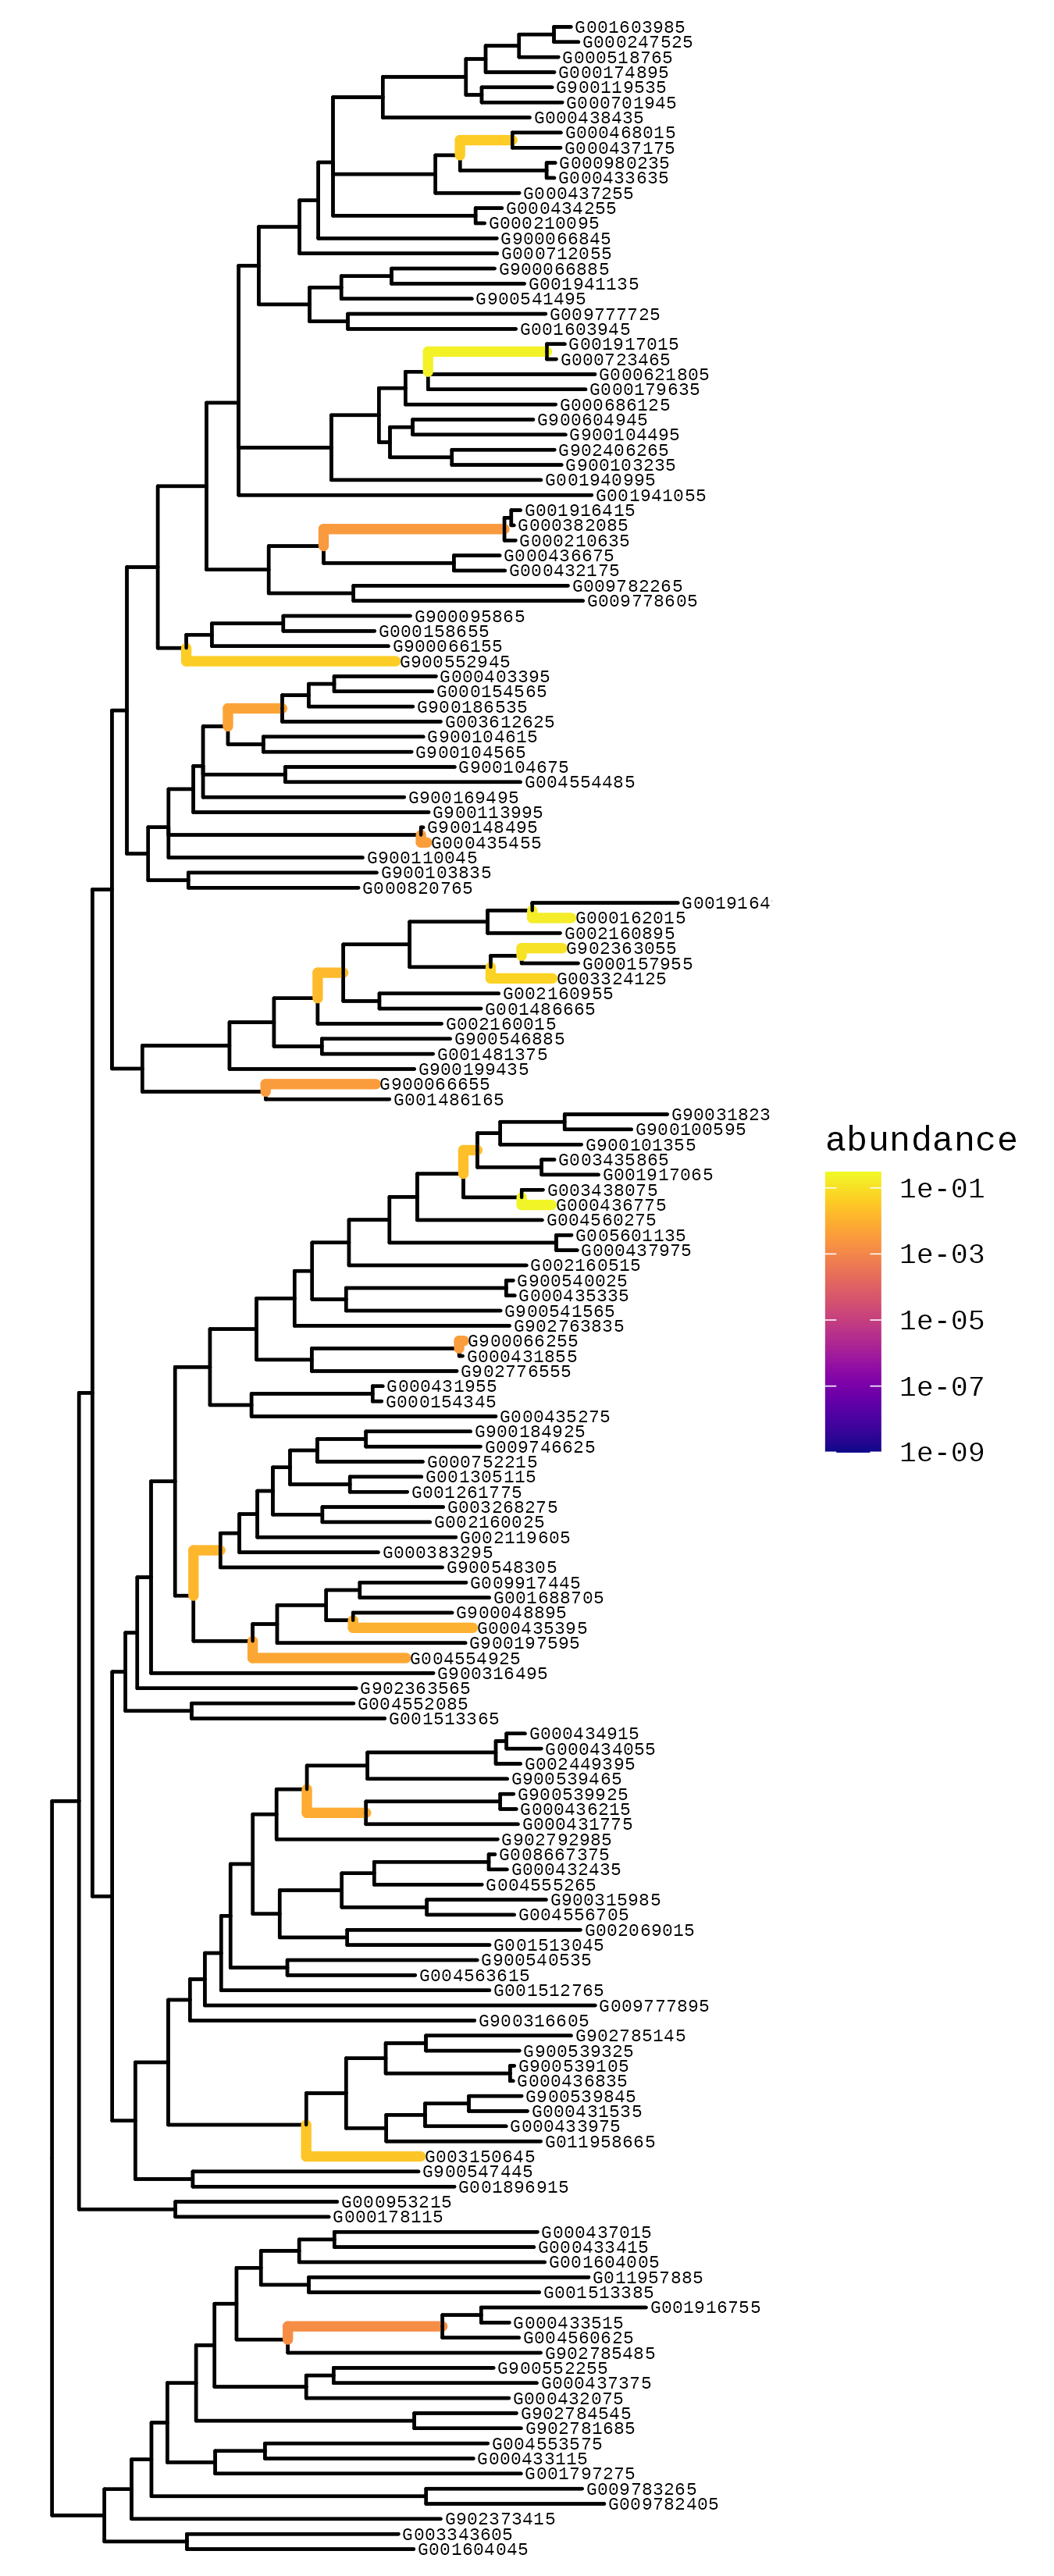

In [51]:
!Rscript MISC/draw_placements.R Example/output/output.jplace "weighted" Example/output/DecoDiPhy_results.png > /dev/null 2>&1
from IPython.display import Image
Image("Example/output/DecoDiPhy_results.png", width=400)